# Fitting causal ratings in a blocking experiment

> **Level** Intermediate · **Time** 25 minutes · **Prerequisites** [Blocking with Bush–Mosteller and Rescorla–Wagner](blocking.ipynb) and [Tutorial 1](../tutorials/first-model.ipynb) ·
> **cpm components** [`SeparableRule`](#cpm.models.learning.SeparableRule), [`DeltaRule`](#cpm.models.learning.DeltaRule), [`Nominal`](#cpm.models.utils.Nominal), [`Wrapper`](#cpm.generators.Wrapper), [`FminBound`](#cpm.optimisation.FminBound), [`Distance`](#cpm.optimisation.minimise.Distance) ·
> **Data** [`load_blocking_data`](#cpm.datasets.load_blocking_data), the blocking experiment of Spicer et al. (2021)

In the [blocking example](blocking.ipynb), only the Rescorla–Wagner model predicted blocking.
Does that mean it also explains a blocking experiment better than the Bush–Mosteller model?
Spicer et al. (2021) fitted both models to the full results of a blocking experiment, all six test cues rather than only the blocked cue and its control.
As usually applied, with every cue starting at an associative strength of zero, the Rescorla–Wagner model fitted no better than the Bush–Mosteller model.
It only fitted better once the starting strength of the cues was a free parameter, which they proposed represents uncertainty about novel cues.

In this example, we recreate the two blocking figures of their paper (Figures 1 and 2), using their data.

**What you'll learn**

- how to turn associative strengths into ratings with a logistic response function,
- how to make the starting state of a model a free parameter,
- how to fit one set of parameters to the mean ratings of a group, with your own loss function in [`FminBound`](#cpm.optimisation.FminBound),
- why fitting all the cues of an experiment, rather than one effect, can change which model wins.

In [ ]:
import cpm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(cpm.__version__)

0.26.0.dev0


## The experiment

Forty-one participants played a doctor, who learns which foods cause stomach ache in a patient.
Each food is a cue, and + means that stomach ache followed, − that it did not.

| Stage 1 | Stage 2 | Test |
|---|---|---|
| A+, B−, C− | AX+, BY+, CD− | A, B, C, D, X, Y |

X is the blocked cue: it was paired with A, which already predicted stomach ache.
Y is its control: it was paired with B, which did not.
C and D are fillers, so that as many trial types were followed by stomach ache as not.
Stage 1 had twelve blocks of its three trial types, and Stage 2 six blocks, each in a random order.
At test, participants rated how likely each food was to cause stomach ache, from 0 (very unlikely) to 10 (very likely), in ten blocks without feedback.

[`load_blocking_data`](#cpm.datasets.load_blocking_data) returns the test ratings, one row per test trial.
Spicer et al. published the data on the [Open Science Framework](https://osf.io/sa8ux/) under a [CC BY 4.0 license](https://creativecommons.org/licenses/by/4.0/).

In [ ]:
from cpm.datasets import load_blocking_data

ratings = load_blocking_data()
ratings.head()

,ppt,block,trial,cue,rating,rt
0,101,1,1,B,0,8.220
1,101,1,2,C,0,1.586
2,101,1,3,D,0,1.536
3,101,1,4,X,0,0.770
4,101,1,5,Y,10,2.453


We average the ratings of each participant over the ten test blocks, and then over participants.

In [ ]:
cue_names = ["A", "B", "C", "D", "X", "Y"]

participant_means = ratings.groupby(["ppt", "cue"]).rating.mean().unstack()[cue_names]
observed = participant_means.mean()
observed.round(2).to_frame("mean rating").T

cue,A,B,C,D,X,Y
mean rating,9.84,1.47,0.35,0.81,4.97,8.42


Participants rated the blocked cue X lower than its control Y, so learning about X was blocked.
But X was not rated low: its mean rating is close to 5, the middle of the scale.

## The models

We use the two learning rules of the [blocking example](blocking.ipynb).
$V_i$ is the associative strength of cue $i$, $R$ is the outcome, and $\alpha$ is the learning rate, which is the same for all cues.

**Bush and Mosteller (1951).** Each cue that is present learns from its own error, independently of the other cues:

$$
\Delta V_i = \alpha \, (R - V_i)
$$

**Rescorla and Wagner (1972).** All cues that are present share one error, the difference between the outcome and their summed prediction:

$$
\Delta V_i = \alpha \left( R - \sum_{j \in \text{present}} V_j \right)
$$

Spicer et al. write the learning rate as the product of a cue salience and an outcome learning rate, and collapse the two into one parameter, $G$, which is our $\alpha$.

Participants gave ratings, not associative strengths.
Following Spicer et al., who in turn follow Gluck and Bower (1988), the rating $P_i$ of cue $i$ is a logistic function of its associative strength:

$$
P_i = \frac{10}{1 + e^{-\theta \, (V_i - \beta)}}
$$

$\beta$ is the associative strength that is rated 5, the middle of the scale, and $\theta$ sets how steeply the rating rises around it.

Before training, every cue has the same starting strength $V_0$:

$$
V_i = V_0 \quad \text{for all cues } i
$$

As usually applied, both models start at $V_0 = 0$.
The model has four parameters: $\alpha$, $\beta$, $\theta$, and, when it is free, $V_0$.

We extend the model function of the [blocking example](blocking.ipynb) in three ways:

- on the first trial, all six associative strengths are set to the starting strength,
- the model predicts a rating from the summed strength of the cues present,
- on test trials there is no feedback, so the strengths are not updated.

Like Spicer et al., we fit ratings divided by 10, so that they are on the same scale as associative strength.

In [ ]:
from functools import partial

from cpm.generators import Parameters, Value, Wrapper
from cpm.models.learning import DeltaRule, SeparableRule
from cpm.models.utils import Nominal


def model(parameters, trial, rule):
    values = np.asarray(parameters.values).copy()
    if trial.trial == 1:
        values[:] = parameters.initial_strength
    cues = np.array([trial.cue_1, trial.cue_2], dtype=int)
    present = Nominal(target=cues[cues > 0], bits=6)

    prediction = np.sum(values * present)
    rating = 1 / (1 + np.exp(-parameters.theta * (prediction - parameters.beta)))
    if trial.phase < 3:  # no feedback at test
        update = rule(weights=values, feedback=[trial.outcome], input=present, alpha=parameters.alpha)
        update.compute()
        values += update.weights.flatten()

    return {"values": values, "prediction": prediction, "rating": rating, "dependent": np.array([rating])}


rules = {"Bush and Mosteller": SeparableRule, "Rescorla and Wagner": DeltaRule}

Next, we write the experiment as a table, with one row per trial, as in the [blocking example](blocking.ipynb).
The cues are numbered A = 1, B = 2, C = 3, D = 4, X = 5 and Y = 6.
Each cue is tested once: learning stops at test, so a second test block would give the same predictions.

The dataset does not include the order in which each participant saw the training trials.
We use one fixed order instead; with learning rates as small as the ones we find below, the order does not change the fitted ratings.

In [ ]:
number = {cue: i + 1 for i, cue in enumerate(cue_names)}


def trials(phase, stimuli, outcomes):
    return [
        {"phase": phase, "cue_1": number[s[0]], "cue_2": number[s[1]] if len(s) > 1 else 0, "outcome": outcome}
        for s, outcome in zip(stimuli, outcomes)
    ]


stage_1 = trials(1, ["A", "B", "C"], [1, 0, 0]) * 12
stage_2 = trials(2, ["AX", "BY", "CD"], [1, 1, 0]) * 6
test = trials(3, cue_names, [0] * 6)
design = pd.DataFrame(stage_1 + stage_2 + test)
design["trial"] = np.arange(1, len(design) + 1)
design.tail(8)

,phase,cue_1,cue_2,outcome,trial
52,2,2,6,1,53
53,2,3,4,0,54
54,3,1,0,0,55
55,3,2,0,0,56
56,3,3,0,0,57
57,3,4,0,0,58
58,3,5,0,0,59
59,3,6,0,0,60


## Fitting the mean ratings

Spicer et al. fitted one set of parameters to the six mean ratings of the group, by minimising the sum of squared errors (SSE) between the predicted and observed ratings.
To do this with [`FminBound`](#cpm.optimisation.FminBound), we treat the whole group as a single participant: the `observed` column holds the mean rating of each cue on its test trial, and nothing on the training trials, where no ratings were made.

The squared-error loss of [`Distance.SSE`](#cpm.optimisation.minimise.Distance.SSE) does not accept missing values, so we write a loss function that passes it the test trials only.

In [ ]:
from cpm.optimisation import FminBound, minimise

design["ppt"] = "group"
design["observed"] = np.nan
test_trials = design.phase.eq(3).to_numpy()
design.loc[test_trials, "observed"] = observed[cue_names].to_numpy() / 10


def test_sse(predicted, observed, **kwargs):
    rated = ~np.isnan(np.ravel(observed))
    return minimise.Distance.SSE(np.ravel(predicted)[rated], np.ravel(observed)[rated])

The parameters get bounds but no informative priors, since we minimise the SSE alone.
The starting strength is a fixed value, or a free parameter between −1 and 1, as in Spicer et al.

In [ ]:
def make_parameters(initial_strength):
    return Parameters(
        alpha=Value(value=0.1, lower=0, upper=1, prior="uniform"),
        beta=Value(value=0.5, lower=0, upper=1, prior="uniform"),
        theta=Value(value=5, lower=0, upper=100, prior="uniform"),
        initial_strength=initial_strength,
        values=np.zeros(6),
    )

The fit can end in a local minimum, so we start the optimiser from a grid of starting values and keep the best fit, as Spicer et al. did.
The error surface of the Bush–Mosteller model is flat along some directions, so we also tighten the stopping rule of the optimiser.
The function below fits both models, and returns their best-fitting parameters, their SSE, and the $R^2$ of the predicted against the observed mean ratings, which Spicer et al. used to judge how well a model fits.

In [ ]:
from itertools import product


def fit_models(initial_strength, guesses):
    summary, predictions = {}, {}
    for name, rule in rules.items():
        wrapper = Wrapper(model=partial(model, rule=rule), parameters=make_parameters(initial_strength), data=design)
        fit = FminBound(
            model=wrapper,
            data=design,
            ppt_identifier="ppt",
            minimisation=test_sse,
            initial_guess=guesses,
            number_of_starts=len(guesses),
            # passed on to scipy.optimize.fmin_l_bfgs_b
            approx_grad=True,
            factr=10,
            pgtol=1e-12,
        )
        fit.optimise(display=False)

        best = {key: float(value) for key, value in fit.parameters[0].items()}
        wrapper.reset(parameters=best)
        wrapper.run()
        predictions[name] = 10 * wrapper.dependent[test_trials].ravel()
        r_squared = np.corrcoef(predictions[name], observed[cue_names])[0, 1] ** 2
        summary[name] = {"initial_strength": float(np.asarray(initial_strength)), **best, "SSE": fit.fit[0]["fun"], "R²": r_squared}
    return pd.DataFrame(summary).T, pd.DataFrame(predictions, index=cue_names)

Spicer et al. show the fits as the predicted mean rating of each cue, against the distribution of the participants' ratings.
We draw the same figure: the grey dots are the mean ratings of individual participants, the black line is the mean of the group, and the two models are drawn on either side of it, so that the distance to the line is the error of the model.

In [ ]:
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
styles = {  # colour and shape, so that the models are not told apart by colour alone
    "Bush and Mosteller": {"color": "#2a78d6", "marker": "o", "offset": -0.15},
    "Rescorla and Wagner": {"color": "#eb6834", "marker": "D", "offset": 0.15},
}


def plot_fit(predictions, title):
    positions = np.arange(len(cue_names))
    jitter = np.random.default_rng(0).uniform(-0.07, 0.07, participant_means.shape)
    fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    violins = ax.violinplot([participant_means[cue] for cue in cue_names], positions=positions, widths=0.8, showextrema=False)
    for body in violins["bodies"]:
        body.set(facecolor="#eeede9", edgecolor="none", alpha=1)
    ax.scatter((positions + jitter).ravel(), participant_means.to_numpy().ravel(), s=10, color="#a9a8a2", linewidths=0, zorder=2, label="participants")
    ax.hlines(observed[cue_names], positions - 0.32, positions + 0.32, color=INK, linewidth=2.5, zorder=3, label="observed mean")
    for name, style in styles.items():
        ax.scatter(
            positions + style["offset"], predictions[name], s=80, color=style["color"], marker=style["marker"],
            edgecolors=SURFACE, linewidths=2, zorder=4, label=name,
        )

    ax.set_xticks(positions, cue_names, fontsize=11, color=INK)
    ax.set_yticks(range(0, 11, 2))
    ax.set_ylim(-0.5, 10.5)
    ax.set_xlim(-0.6, len(cue_names) - 0.4)
    ax.set_xlabel("cue", color=MUTED)
    ax.set_ylabel("mean causal rating", color=MUTED)
    ax.tick_params(length=0, colors=MUTED)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_title(title, loc="left", color=INK, fontsize=12, pad=30)
    legend = ax.legend(
        ncol=4, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=9, labelcolor=MUTED,
        handletextpad=0.3, columnspacing=1.2, borderaxespad=0.3,
    )
    legend.legend_handles[0].set_sizes([30])  # the participant dots are too small to read in the legend
    plt.tight_layout()
    plt.show()

The values that Spicer et al. report for their fits (Tables S2 and S3 of their supplementary materials) are below, for comparison.
They are rounded to two decimal places.

In [ ]:
reported = pd.DataFrame(
    [
        ["zero", "Bush and Mosteller", 0.00, 0.04, 0.21, 13.41, 0.24, 0.71],
        ["zero", "Rescorla and Wagner", 0.00, 0.01, 0.04, 75.81, 0.24, 0.71],
        ["free", "Bush and Mosteller", 0.45, 0.02, 0.49, 30.52, 0.06, 0.93],
        ["free", "Rescorla and Wagner", 0.43, 0.04, 0.41, 19.31, 0.00, 1.00],
    ],
    columns=["starting strength", "model", "initial_strength", "alpha", "beta", "theta", "SSE", "R²"],
).set_index(["starting strength", "model"])

## All cues start at zero

We first fit the models as they are usually applied, with every cue starting at zero.
There are three free parameters, so the grid has $2^3 = 8$ starting points.

In [ ]:
grid = [(0.05, 0.25), (0.25, 0.75), (1, 3)]  # alpha, beta, theta
zero_summary, zero_predictions = fit_models(0.0, np.array(list(product(*grid))))

pd.concat({"cpm": zero_summary, "Spicer et al. (2021)": reported.loc["zero"]}).round(3)

initial_strength  alpha   beta  \
cpm                  Bush and Mosteller                0.0  0.032  0.179   
                     Rescorla and Wagner               0.0  0.005  0.027   
Spicer et al. (2021) Bush and Mosteller                0.0  0.040  0.210   
                     Rescorla and Wagner               0.0  0.010  0.040   

                                            theta    SSE     R²  
cpm                  Bush and Mosteller    15.554  0.242  0.711  
                     Rescorla and Wagner  100.000  0.244  0.710  
Spicer et al. (2021) Bush and Mosteller    13.410  0.240  0.710  
                     Rescorla and Wagner   75.810  0.240  0.710

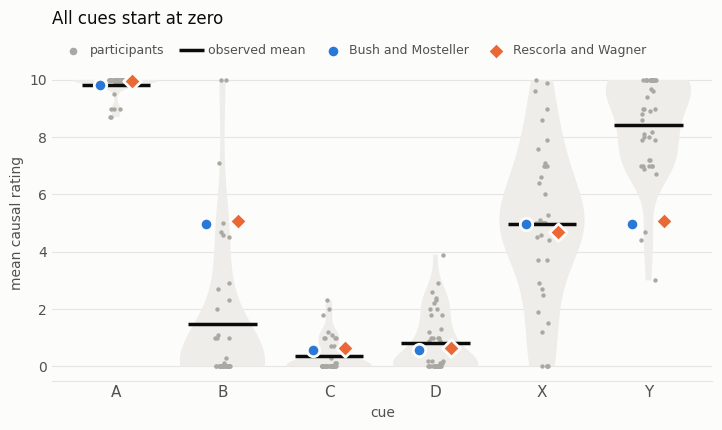

In [ ]:
plot_fit(zero_predictions, "All cues start at zero")

This is Figure 1 of Spicer et al.: both models fit equally poorly, with an SSE of 0.24 and an $R^2$ of 0.71.
The Rescorla–Wagner model predicts blocking, since it rates X lower than Y, but the difference is small, and neither model captures the low rating of B or the high rating of Y.

The problem is the starting strength.
After the B− trials of Stage 1, B still has an associative strength of zero, just like the new cue Y.
In Stage 2, B and Y are then trained together on BY+ trials, so both models predict the same rating for them, although participants rated B 1.5 and Y 8.4.
The best the models can do is to learn very little, and use a steep response function to place B, X and Y near the middle of the scale.
The fitted Rescorla–Wagner model takes this to the extreme: its learning rate is close to zero, and $\theta$ is at its upper bound of 100, so that the response function is almost a step.
Its parameters differ from the reported ones for this reason; the fit is equally good.

## Starting from uncertainty

A rat that has never encountered a cue has not learned anything about it, so its associative strength should start at zero.
A participant who sees a new food, however, does not know whether it causes stomach ache or not.
Spicer et al. proposed that the associative strength of a novel cue should start at an intermediate value, which reflects this uncertainty, and they made the starting strength a free parameter.
If it represents uncertainty, the best-fitting value should be near the middle of the range of associative strengths.

We make the starting strength a free parameter, with a uniform prior between −1 and 1, and add it to the grid of starting points.

In [ ]:
initial_strength = Value(value=0.5, lower=-1, upper=1, prior="uniform")
grid = [(0.05, 0.25), (0.25, 0.75), (1, 3), (0.25, 0.75)]  # alpha, beta, theta, initial_strength
free_summary, free_predictions = fit_models(initial_strength, np.array(list(product(*grid))))

pd.concat({"cpm": free_summary, "Spicer et al. (2021)": reported.loc["free"]}).round(3)

initial_strength  alpha   beta  \
cpm                  Bush and Mosteller              0.417  0.006  0.429   
                     Rescorla and Wagner             0.428  0.043  0.410   
Spicer et al. (2021) Bush and Mosteller              0.450  0.020  0.490   
                     Rescorla and Wagner             0.430  0.040  0.410   

                                           theta    SSE     R²  
cpm                  Bush and Mosteller   87.679  0.060  0.928  
                     Rescorla and Wagner  19.317  0.001  0.999  
Spicer et al. (2021) Bush and Mosteller   30.520  0.060  0.930  
                     Rescorla and Wagner  19.310  0.000  1.000

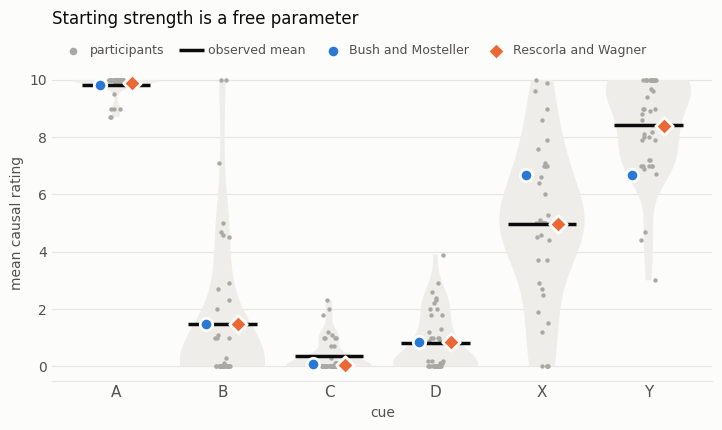

In [ ]:
plot_fit(free_predictions, "Starting strength is a free parameter")

This is Figure 2 of Spicer et al.
With a free starting strength, the Rescorla–Wagner model fits the mean ratings almost perfectly ($R^2 = 1.00$), and its best-fitting parameters are the reported ones.
The best-fitting starting strength is 0.43, an intermediate value, as the uncertainty account predicts.

Both models now separate B from Y: B loses associative strength on the B− trials of Stage 1, while Y enters Stage 2 at the starting strength.
Only the Rescorla–Wagner model also separates X from Y.
At the end of Stage 1, A predicts stomach ache, so the summed prediction of A and X on AX+ trials is close to the outcome, and X barely learns.
X ends the experiment close to where it started, near $\beta$, so it is rated close to 5: the model is as uncertain about X as it was about any new food.
The Bush–Mosteller model has no summed error, so X and Y learn in the same way, and it predicts the same rating for both.

The Bush–Mosteller parameters differ from the reported ones, because the model predicts almost the same ratings for a range of parameter values.
Our fit has an SSE of 0.060, and the reported parameters give 0.061.

## Summary and next steps

You fitted two learning models to the mean ratings of a blocking experiment, with a logistic response function and a starting strength that can be a free parameter, and recreated Figures 1 and 2 of Spicer et al. (2021).
When all the test cues are fitted, the Rescorla–Wagner model only explains the experiment better than the Bush–Mosteller model if novel cues start at an intermediate associative strength.

To take this further:

- Spicer et al. go on to fit the redundancy effect, and a manipulation of the outcome base rate (Jones et al., 2019), with the same models; their data and code are linked from the [supplementary materials](https://osf.io/7u6re/).
- To fit a model to each participant, rather than to the mean of a group, see [Tutorial 1: Build and fit your first model](../tutorials/first-model.ipynb).

This example is based on a first version by Zhaotong Jia.

## References

Bush, R. R., & Mosteller, F. (1951). A mathematical model for simple learning. *Psychological Review*, 58(5), 313–323. https://doi.org/10.1037/h0054388

Gluck, M. A., & Bower, G. H. (1988). From conditioning to category learning: An adaptive network model. *Journal of Experimental Psychology: General*, 117(3), 227–247. https://doi.org/10.1037/0096-3445.117.3.227

Jones, P. M., Zaksaite, T., & Mitchell, C. J. (2019). Uncertainty and blocking in human causal learning. *Journal of Experimental Psychology: Animal Learning and Cognition*, 45(1), 111–124. https://doi.org/10.1037/xan0000185

Rescorla, R. A., & Wagner, A. R. (1972). A theory of Pavlovian conditioning: Variations in the effectiveness of reinforcement and nonreinforcement. In A. H. Black & W. F. Prokasy (Eds.), *Classical conditioning II: Current research and theory* (pp. 64–99). Appleton-Century-Crofts.

Spicer, S. G., Wills, A. J., Jones, P. M., Mitchell, C. J., & Dome, L. (2021). Representing uncertainty in the Rescorla-Wagner model: Blocking, the redundancy effect, and outcome base rate. *Open Journal of Experimental Psychology and Neuroscience*, 1, 14–21. https://doi.org/10.46221/ojepn.2021.6623